**Configuration note:** the input paths used by this notebook mirror `config.sh` at the repository root. The variables are defined in the next cell — edit them (or `config.sh`) to point at your own data. The remaining cells still contain the original absolute paths from the primary run.


In [ ]:
# Input paths — edit these (or config.sh at the repo root) for your environment.
PROJ_ROOT = "/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj"
CODE_DIR  = f"{PROJ_ROOT}/code/command-line-script"

input_dir      = f"{CODE_DIR}/contig-coverage/2-primaryreads-coverage/"
coverage_long  = f"{CODE_DIR}/contig-coverage/coverage_long_read_hifiasm_041425_scaffolded_juiceBox_sorted_hardMasked_15kb_windows.tsv"
coverage_short = f"{CODE_DIR}/contig-coverage/coverage_short_read_hifiasm_041425_scaffolded_juiceBox_sorted_hardMasked_chrAssigned_15kb_windows_filtered.tsv"


# Goal of this notebook
Plot a violin plot of the masked coverage
Plot the overall kmer share for each chromosome ; These should all be not chrAssigned reference data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import math
from matplotlib.pyplot import figure
from natsort import natsorted
import matplotlib.gridspec as gridspec
import seaborn as sns


Remember the seq that start with PGA_scaffold_1_ etc is not sorted yet just the immediate output of the juicebox program

In [2]:
## Set up common variable
input_dir="/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj/code/command-line-script/contig-coverage/2-primaryreads-coverage/"


In [3]:
cov_long = pd.read_csv(input_dir+"coverage_long_read_hifiasm_041425_scaffolded_juiceBox_sorted_primaryRead_contig.tsv", sep="\t", names=['contig','start_pos','end_pos','coverage'])
# # If you need to extract just the contig names:
cov_long = cov_long.head(30)
# # Replace 'seq' with 'chr' for the selected contigs
# cov_hm['contig'] = cov_hm['contig'].str.replace('seq', 'chr')
# Replace scaffold names with chr{i}
cov_long = cov_long.sort_values("end_pos", ascending=False)
cov_long['contig'] = '' + (cov_long.index + 1).astype(str)
cov_long = cov_long.iloc[natsorted(cov_long['contig'].index, key=lambda x: cov_long['contig'][x])]
# Reset index if needed
cov_long = cov_long.reset_index(drop=True)
cov_long

,contig,start_pos,end_pos,coverage
0,1,0,197914338,20.713079
1,2,0,185300982,36.563721
2,3,0,158109495,34.293339
3,4,0,152493930,36.891727
4,5,0,151562733,35.041534
5,6,0,142911117,38.923534
6,7,0,138704743,38.036941
7,8,0,138367390,36.392899
8,9,0,134185266,36.759655
9,10,0,133551988,37.814411


In [4]:
cov_long_hm = pd.read_csv(input_dir+"coverage_long_read_hifiasm_041425_scaffolded_juiceBox_sorted_hardMasked_primaryRead_contig.tsv", sep="\t", names=['contig','start_pos','end_pos','coverage'])
# # If you need to extract just the contig names:
selected_contigs = [f"seq{i}" for i in range(1, 31)]
cov_long_hm = cov_long_hm[cov_long_hm['contig'].isin(selected_contigs)]
# Replace 'seq' with 'chr' for the selected contigs
cov_long_hm['contig'] = cov_long_hm['contig'].str.replace('seq', '')
cov_long_hm

,contig,start_pos,end_pos,coverage
0,1,0,197914338,5.504729
1,2,0,185300982,20.916252
2,3,0,158109495,9.893475
3,4,0,152493930,14.035088
4,5,0,151562733,10.361381
5,6,0,142911117,15.097401
6,7,0,138704743,15.921681
7,8,0,138367390,18.038898
8,9,0,134185266,14.514503
9,10,0,133551988,15.303977


In [5]:
cov_short = pd.read_csv(input_dir+"coverage_short_read_hifiasm_041425_scaffolded_juiceBox_sorted_primaryRead_contig.tsv", sep="\t", names=['contig','start_pos','end_pos','coverage'])

# # # If you need to extract just the contig names:
cov_short = cov_short[cov_short['contig'].str.startswith(tuple([f"PGA_scaffold_{i}__" for i in range(1, 31)]))]
# # Replace 'seq' with 'chr' for the selected contigs
# cov_hm['contig'] = cov_hm['contig'].str.replace('seq', 'chr')
# Replace scaffold names with chr{i}
cov_short = cov_short.sort_values("end_pos", ascending=False)
cov_short['contig'] = '' + (cov_short.index + 1).astype(str)

cov_short = cov_short.iloc[natsorted(cov_short['contig'].index, key=lambda x: cov_short['contig'][x])]
# Reset index if needed
cov_short = cov_short.reset_index(drop=True)
cov_short

,contig,start_pos,end_pos,coverage
0,1,0,197914338,72.254059
1,2,0,185300982,95.057610
2,3,0,158109495,85.957985
3,4,0,152493930,90.487495
4,5,0,151562733,88.944534
5,6,0,142911117,91.451363
6,7,0,138704743,92.271057
7,8,0,138367390,88.296440
8,9,0,134185266,86.072243
9,10,0,133551988,91.853065


In [6]:
cov_short_hm = pd.read_csv(input_dir+"coverage_short_read_hifiasm_041425_scaffolded_juiceBox_sorted_hardMasked_primaryRead_contig.tsv", sep="\t", names=['contig','start_pos','end_pos','coverage'])
# # If you need to extract just the contig names:
selected_contigs = [f"seq{i}" for i in range(1, 31)]
cov_short_hm = cov_short_hm[cov_short_hm['contig'].isin(selected_contigs)]
# Replace 'seq' with 'chr' for the selected contigs
cov_short_hm['contig'] = cov_short_hm['contig'].str.replace('seq', '')
cov_short_hm

,contig,start_pos,end_pos,coverage
0,1,0,197914338,41.543346
1,2,0,185300982,104.060677
2,3,0,158109495,41.557034
3,4,0,152493930,55.796185
4,5,0,151562733,44.104843
5,6,0,142911117,51.012390
6,7,0,138704743,76.317947
7,8,0,138367390,86.353180
8,9,0,134185266,52.605255
9,10,0,133551988,51.195686


In [7]:
# Combine with a new 'source' column
cov = pd.concat([cov_long, cov_long_hm,cov_short,cov_short_hm], keys=["long_read", "long_read_hm", "short_read", "short_read_hm"], names=["source", "original_index"])
cov = cov.reset_index(level="source")  # Flatten the 'source' index into a column
cov = cov.reset_index(drop=True)      # Drop the original index (optional)
cov

,source,contig,start_pos,end_pos,coverage
0,long_read,1,0,197914338,20.713079
1,long_read,2,0,185300982,36.563721
2,long_read,3,0,158109495,34.293339
3,long_read,4,0,152493930,36.891727
4,long_read,5,0,151562733,35.041534
...,...,...,...,...,...
115,short_read_hm,26,0,64753882,68.362816
116,short_read_hm,27,0,60231632,51.379589
117,short_read_hm,28,0,53369913,51.114094
118,short_read_hm,29,0,53342293,132.751175


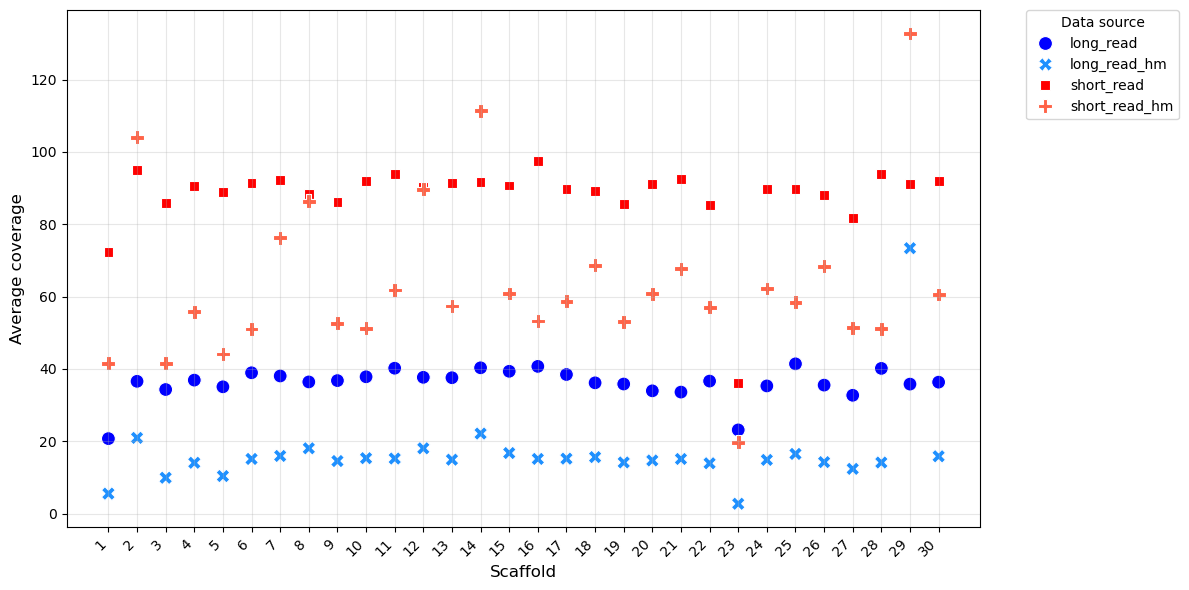

In [8]:
# Set up the figure
plt.figure(figsize=(12, 6))

# Ensure contigs are sorted naturally
cov["contig"] = pd.Categorical(cov["contig"], natsorted(cov["contig"].unique()))

# Custom color palette
palette_c = {
    "long_read": "blue", 
    "long_read_hm": "dodgerblue", 
    "short_read": "red",
    "short_read_hm": "tomato"
}

# Create the scatter plot and store the plot object
plot = sns.scatterplot(
    data=cov,
    x="contig",          # X-axis: Contigs (chr1, chr2, ...)
    y="coverage",        # Y-axis: Coverage values
    hue="source",        # Color dots by source
    style="source",      # Different marker styles per source
    s=100,               # Dot size
    palette=palette_c,   # Our custom color palette
)

# Custom legend labels
new_labels = {
    "long_read": "Long read",
    "long_read_hm": "Long read with \n hardmasked assembly",
    "short_read": "Short Reads",
    "short_read_hm": "Short reads with \n hardmasked assembly"
}

# Get the legend and update labels
legend = plot.legend()
for text, label in zip(legend.get_texts(), new_labels.values()):
    text.set_text(label)

# Axis labels and formatting
plt.xlabel("Scaffold", fontsize=12)
plt.ylabel("Average coverage", fontsize=12)
plt.xticks(rotation=45, ha="right")  # Rotate contig labels
plt.grid(alpha=0.3)                 # Add light gridlines

# Adjust legend position and title
plt.legend(
    bbox_to_anchor=(1.05, 1), 
    loc='upper left',
    title="Data source",
    frameon=True,
    borderaxespad=0.
)

# Final layout adjustment
plt.tight_layout()
plt.show()

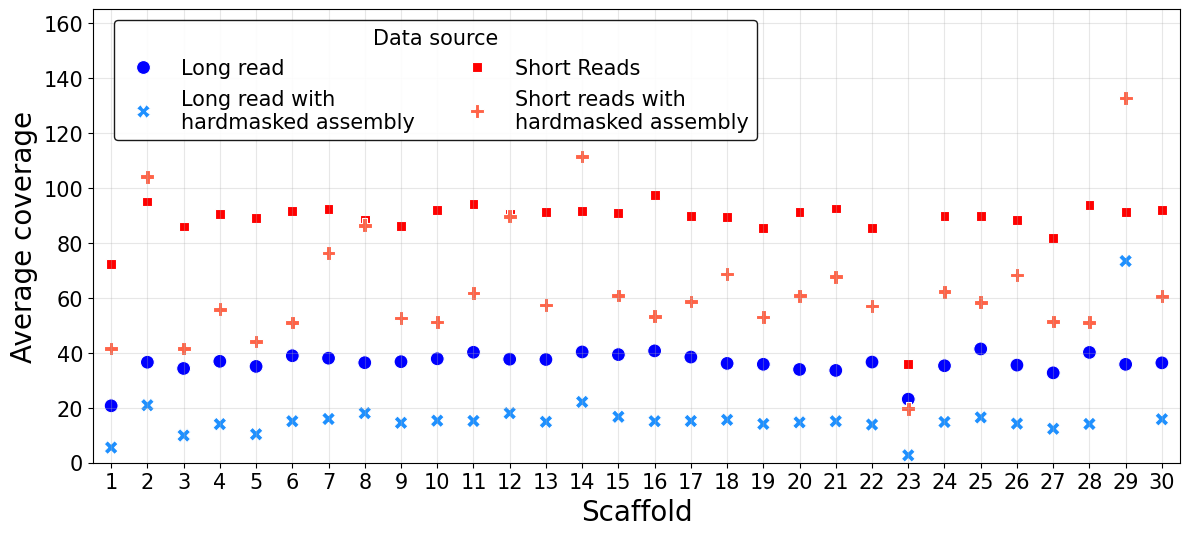

Plot saved as 'kmer_plot_primaryReads.png'


In [17]:

# 1. Create new column with pretty labels
label_map = {
    "long_read": "Long read",
    "long_read_hm": "Long read with\nhardmasked assembly",
    "short_read": "Short Reads", 
    "short_read_hm": "Short reads with\nhardmasked assembly"
}
cov['source_label'] = cov['source'].map(label_map)

# 2. Set up colors (now using the original 'source' for color mapping)
palette_c = {
    "Long read": "blue",
    "Long read with\nhardmasked assembly": "dodgerblue",
    "Short Reads": "red",
    "Short reads with\nhardmasked assembly": "tomato"
}

width_cm = 7.7042
height_cm = 3.5104
# Set up the plot with proportional dimensions
plt.figure(figsize=(12, 12*height_cm/width_cm))


# Ensure contigs are sorted naturally
cov["contig"] = pd.Categorical(cov["contig"], natsorted(cov["contig"].unique()))


# Create the scatter plot and store the plot object
plot = sns.scatterplot(
    data=cov,
    x="contig",          # X-axis: Contigs (chr1, chr2, ...)
    y="coverage",        # Y-axis: Coverage values
    hue="source_label",        # Color dots by source
    style="source_label",      # Different marker styles per source
    s=100,               # Dot size
    palette=palette_c,   # Our custom color palette
)
plot.set_xlim(-0.5, len(cov['contig'].unique())-0.5)  # Add 0.5 padding on both ends



# Axis labels and formatting
plt.xlabel("Scaffold", fontsize=20)
plt.ylabel("Average coverage", fontsize=20)
plt.xticks( ha="center",fontsize=15)  # Rotate contig labels
plt.yticks(fontsize=15)  # Rotate contig labels
plt.ylim([0,165])  # Rotate contig labels


# Replace the legend command with this:
plt.legend(
    loc='upper left',          # Position in upper left inside plot
    bbox_to_anchor=(0.01, 1),    # Fine-tune position (x,y coordinates)
    title="Data source",
    title_fontsize=15,
    ncol=2,                   # Single column looks better inside plot
    fontsize=15,              # Slightly smaller font
    facecolor='white',        # Add white background
    edgecolor='black',        # Add border
    framealpha=0.9           # Slightly transparent
)
plt.grid(alpha=0.3)                 # Add light gridlines



# Final layout adjustment
plt.tight_layout()
# Save with high quality settings
plt.savefig('coverage_dotplot_primaryReads.png',
           dpi=300,
           bbox_inches='tight',
           facecolor='white')  # Ensures white background

plt.show()  # Close the figure

print("Plot saved as 'kmer_plot_primaryReads.png'")

## Plotting 15 kb coverage as violin plots ==> messy

In [53]:
## Read in coverage
## Load in the coverage of long read on hard masked assembled contigs 
# cov_hm = pd.read_csv("/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj/code/command-line-script/contig-coverage/coverage_short_read_hifiasm_041425_scaffolded_juiceBox_sorted_hardMasked_chrAssigned_15kb_windows_filtered.tsv", sep="\t", names=['contig','start_pos','end_pos','coverage'])
# cov_hm =cov_hm[cov_hm['contig'].str.contains("chr")]

# cov_hm = pd.read_csv("/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj/code/command-line-script/contig-coverage/coverage_short_read_hifiasm_041425_scaffolded_juiceBox_sorted_hardMasked_chrAssigned_15kb_windows_filtered.tsv", sep="\t", names=['contig','start_pos','end_pos','coverage'])
# cov_hm =cov_hm[cov_hm['contig'].str.contains("chr")]

cov_hm = pd.read_csv("/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj/code/command-line-script/contig-coverage/coverage_long_read_hifiasm_041425_scaffolded_juiceBox_sorted_hardMasked_15kb_windows.tsv", sep="\t", names=['contig','start_pos','end_pos','coverage'])
# # If you need to extract just the contig names:
selected_contigs = [f"seq{i}" for i in range(1, 31)]
cov_hm = cov_hm[cov_hm['contig'].isin(selected_contigs)]
# Replace 'seq' with 'chr' for the selected contigs
cov_hm['contig'] = cov_hm['contig'].str.replace('seq', 'chr')



In [54]:
cov_hm

,contig,start_pos,end_pos,coverage
0,chr1,0,15000,0.000000
1,chr1,15000,30000,12.467600
2,chr1,30000,45000,3.627400
3,chr1,45000,60000,3.690200
4,chr1,60000,75000,0.000000
...,...,...,...,...
225440,chr30,44595000,44610000,70.885803
225441,chr30,44610000,44625000,3.582933
225442,chr30,44625000,44640000,4.487133
225443,chr30,44640000,44655000,7.814267


In [55]:
# plt.figure(figsize=(10, 4))
# plt.plot(df['start_pos'], df['coverage'], 'o', markersize=1, alpha=0.5)
# plt.yscale('log')
# plt.xlabel('Genomic Position')
# plt.ylabel('Coverage (log scale)')
# plt.title('Genome-wide Coverage Distribution')
# plt.show()

In [56]:
cov_hm.sort_values(by="coverage",ascending=False)

,contig,start_pos,end_pos,coverage
220828,chr29,28770000,28785000,383478.781250
21715,chr2,127800000,127815000,340535.250000
127850,chr14,8610000,8625000,158405.906250
77115,chr8,29670000,29685000,132455.234375
113650,chr12,44895000,44910000,100692.875000
...,...,...,...,...
56054,chr5,146955000,146970000,0.000000
56052,chr5,146925000,146940000,0.000000
56051,chr5,146910000,146925000,0.000000
6827,chr1,102405000,102420000,0.000000


In [57]:
cov_hm[cov_hm["contig"]=="chr2"].sort_values(by="coverage",ascending=False)

,contig,start_pos,end_pos,coverage
21715,chr2,127800000,127815000,340535.250000
21716,chr2,127815000,127830000,85711.554688
21794,chr2,128985000,129000000,620.713135
15487,chr2,34380000,34395000,362.803131
21776,chr2,128715000,128730000,353.192261
...,...,...,...,...
21729,chr2,128010000,128025000,0.000000
21730,chr2,128025000,128040000,0.000000
21731,chr2,128040000,128055000,0.000000
21732,chr2,128055000,128070000,0.000000


In [58]:
df

,contig,start_pos,end_pos,coverage
0,chr1,0,15000,0.000000
1,chr1,15000,30000,12.467600
2,chr1,30000,45000,3.627400
3,chr1,45000,60000,3.690200
4,chr1,60000,75000,0.000000
...,...,...,...,...
225440,chr30,44595000,44610000,70.885803
225441,chr30,44610000,44625000,3.582933
225442,chr30,44625000,44640000,4.487133
225443,chr30,44640000,44655000,7.814267


/tscc/lustre/ddn/scratch/jhc103/temp-dir-fast/ipykernel_3499750/2466677784.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_coverage = df_filtered.groupby('contig')['coverage'].median().reset_index()


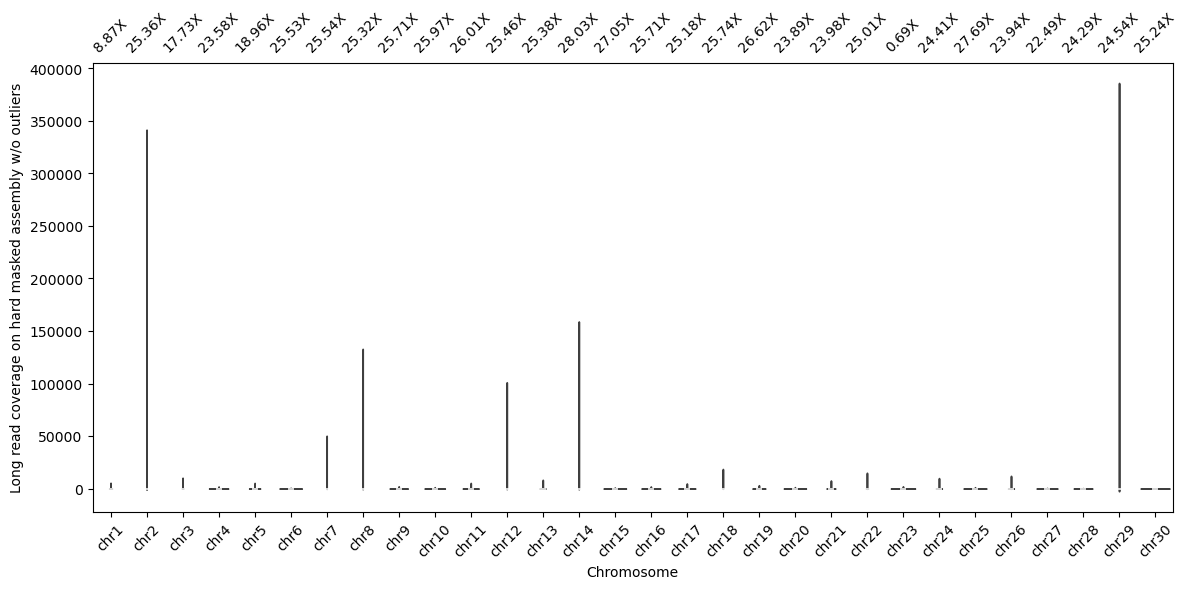

In [59]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt
# import numpy as np
# from natsort import natsorted  # For natural sorting

# Copy and prepare data
df = cov_hm.copy()
df['coverage'] = pd.to_numeric(df['coverage'], errors='coerce')

# IQR filtering
Q1 = df['coverage'].quantile(0.25)
Q3 = df['coverage'].quantile(0.75)
IQR = Q3 - Q1
# df_filtered = df[(df['coverage'] >= Q1 - 1.5*IQR) & (df['coverage'] <= Q3 + 1.5*IQR)]
# df_filtered = df[df['coverage'] <1000]
# df_filtered = df[df['coverage'] <100]
df_filtered = df

# Natural sort chromosomes
chrom_order = natsorted(df_filtered['contig'].unique())
df_filtered['contig'] = pd.Categorical(df_filtered['contig'], categories=chrom_order, ordered=True)
median_coverage = df_filtered.groupby('contig')['coverage'].median().reset_index()

# Plotting
plt.figure(figsize=(12, 6))
ax = sns.violinplot(data=df_filtered, x='contig', y='coverage', order=chrom_order)

# Add median annotations
for i, contig in enumerate(chrom_order):
    median_val = median_coverage.loc[median_coverage['contig'] == contig, 'coverage'].values[0]
    ax.text(i, ax.get_ylim()[1] * 1.02, f'{median_val:.2f}X', 
            ha='center', va='bottom', fontsize=10, color='black', rotation=45)

plt.xlabel('Chromosome')
plt.ylabel('Long read coverage on hard masked assembly w/o outliers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [60]:
df[df["coverage"]<0]

,contig,start_pos,end_pos,coverage


/tscc/lustre/ddn/scratch/jhc103/temp-dir-fast/ipykernel_3499750/557343759.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_coverage = df.groupby('contig')['coverage'].median().reset_index()


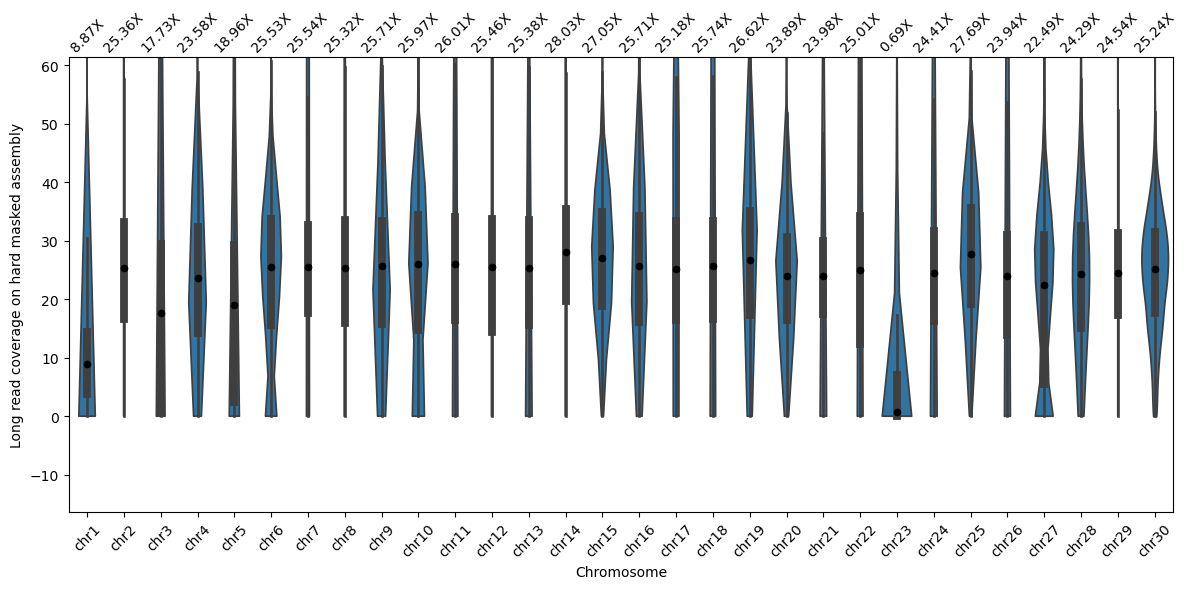

In [61]:
# Copy and prepare data
df = cov_hm.copy()
df['coverage'] = pd.to_numeric(df['coverage'], errors='coerce')

# Calculate IQR bounds
Q1 = df['coverage'].quantile(0.25)
Q3 = df['coverage'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

# Natural sort chromosomes
chrom_order = natsorted(df['contig'].unique())
df['contig'] = pd.Categorical(df['contig'], categories=chrom_order, ordered=True)

# Calculate mean using ALL data
mean_coverage = df.groupby('contig')['coverage'].median().reset_index()

# Plotting - original style
plt.figure(figsize=(12, 6))
ax = sns.violinplot(data=df, x='contig', y='coverage', order=chrom_order, cut=0)

# Clip y-axis
ax.set_ylim(lower_bound, upper_bound)

# Add mean as subtle black dots (no legend)
sns.stripplot(data=mean_coverage, x='contig', y='coverage',
              color='black', marker='o', size=5, ax=ax, linewidth=0.5)

# Original median annotations (now showing means)
for i, contig in enumerate(chrom_order):
    mean_val = mean_coverage.loc[mean_coverage['contig'] == contig, 'coverage'].values[0]
    ax.text(i, upper_bound * 1.01, f'{mean_val:.2f}X',
            ha='center', va='bottom', fontsize=10, color='black', rotation=45)

# Original styling
plt.xlabel('Chromosome')
plt.ylabel('Long read coverage on hard masked assembly')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tscc/lustre/ddn/scratch/jhc103/temp-dir-fast/ipykernel_3909768/2485157598.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_coverage = df.groupby('contig')['coverage'].mean().reset_index()


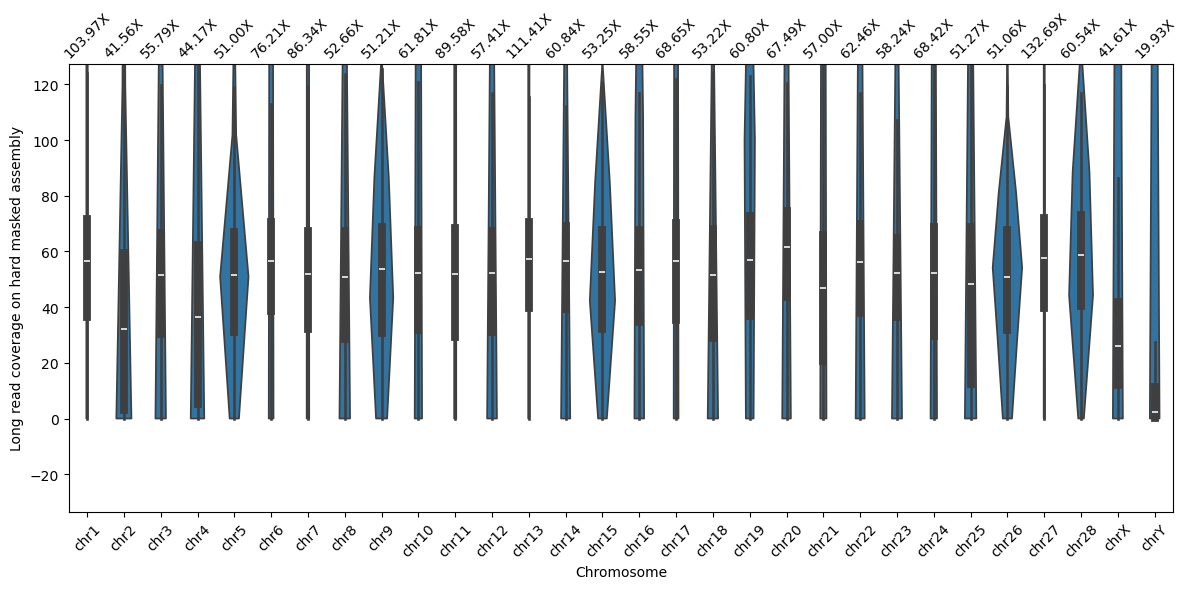

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from natsort import natsorted

# Copy and prepare data
df = cov_hm.copy()
df['coverage'] = pd.to_numeric(df['coverage'], errors='coerce')

# Calculate IQR bounds (for visualization only)
Q1 = df['coverage'].quantile(0.25)
Q3 = df['coverage'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

# Natural sort chromosomes
chrom_order = natsorted(df['contig'].unique())
df['contig'] = pd.Categorical(df['contig'], categories=chrom_order, ordered=True)

# Calculate median using ALL data (not filtered)
median_coverage = df.groupby('contig')['coverage'].mean().reset_index()

# Plotting - identical to your original style
plt.figure(figsize=(12, 6))
ax = sns.violinplot(data=df, x='contig', y='coverage', order=chrom_order,cut=0)

# The only changes needed:
# 1. Clip the y-axis to show only IQR range
ax.set_ylim(lower_bound, upper_bound)

# 2. Keep your original median annotations (but now using full data)
for i, contig in enumerate(chrom_order):
    median_val = median_coverage.loc[median_coverage['contig'] == contig, 'coverage'].values[0]
    ax.text(i, upper_bound * 1.01, f'{median_val:.2f}X',  # Position relative to new upper bound
            ha='center', va='bottom', fontsize=10, color='black', rotation=45)

# Rest is exactly your original styling
plt.xlabel('Chromosome')
plt.ylabel('Long read coverage on hard masked assembly')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()